## Assignment 5 

Biljana Vitanova, Sara Milovanova 

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

In [2]:
import dask.dataframe as dd
from dask import compute

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import numpy as np
import duckdb
import time

In [5]:
from dask_sql import Context

In [6]:
import shutil
from glob import glob

## 1. Data Preprocessing

In [7]:
data_dir = Path("data")
parquet_files = sorted(data_dir.glob("*.parquet"))

# read all parquet files into a single Dask DataFrame
ddf = dd.read_parquet(
    str(data_dir / "*.parquet"),
    engine="pyarrow",
    include_path_column="source_file"
)

# total number of parquet files
n_files = len(parquet_files)

# number of dask partitions created
n_partitions = ddf.npartitions

# data types of the columns
dtypes = ddf.dtypes

# summary information 
n_files, n_partitions, dtypes

(206,
 206,
 VendorID                           float64
 tpep_pickup_datetime        datetime64[ns]
 tpep_dropoff_datetime       datetime64[ns]
 passenger_count                    float64
 trip_distance                      float64
 RatecodeID                         float64
 store_and_fwd_flag                  string
 PULocationID                         Int64
 DOLocationID                         Int64
 payment_type                       float64
 fare_amount                        float64
 extra                              float64
 mta_tax                            float64
 tip_amount                         float64
 tolls_amount                       float64
 improvement_surcharge              float64
 total_amount                       float64
 congestion_surcharge               float64
 airport_fee                        float64
 year                              category
 pickup_time_hour            datetime64[ns]
 temperature_c                      float64
 precipitation_mm   

In [ ]:
n_rows = ddf.shape[0].compute()
n_cols = ddf.shape[1]

print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 171687164
Columns: 35


### 1.1 Missing values

The column **`airport_fee`** contains the highest number of missing values with approximately **116 million** missing entries, which is expected since airport fees apply only to airport-related trips.

The columns **`congestion_surcharge`**, **`passenger_count`**, **`store_and_fwd_flag`**, and **`RatecodeID`** also contain missing values, ranging from approximately **3.8 million to 8.6 million** records.

Weather-related features including **`temperature_c`**, **`windspeed_kmh`**, **`rain_mm`**, **`cloudcover_pct`**, and **`precipitation_mm`** contain only around **108 thousand** missing values each, which is relatively small compared to the full dataset size.

All remaining columns contain no missing values.

In [8]:
missing_values = (
    ddf.isna()
       .sum()
       .compute()
       .sort_values(ascending=False)
)
missing_values

airport_fee                 115951378
congestion_surcharge          8652451
passenger_count               3796299
store_and_fwd_flag            3796299
RatecodeID                    3796299
temperature_c                  108571
windspeed_kmh                  108571
rain_mm                        108571
cloudcover_pct                 108571
precipitation_mm               108571
VendorID                            0
tpep_dropoff_datetime               0
tpep_pickup_datetime                0
extra                               0
payment_type                        0
fare_amount                         0
DOLocationID                        0
PULocationID                        0
trip_distance                       0
improvement_surcharge               0
total_amount                        0
tip_amount                          0
tolls_amount                        0
mta_tax                             0
pickup_time_hour                    0
year                                0
pickup_schoo

In [9]:
zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")
zones_lookup = zones[["LocationID", "borough", "zone"]].copy() # use only relevant columns for lookup 
zones_lookup["LocationID"] = zones_lookup["LocationID"].astype("Int64")

# merge pickup location ID with taxi zone lookup
ddf = ddf.merge(
    zones_lookup,
    # match pickup location IDs
    left_on="PULocationID",
    right_on="LocationID",
    # keep all taxi trip rows
    how="left"
)

ddf = ddf.rename(columns={
    "borough": "PU_Borough",
    "zone": "PU_Zone",
})

# remove duplicate LocationID column after merge
ddf = ddf.drop(columns=["LocationID"])

# merge dropoff location ID with taxi zone lookup
ddf = ddf.merge(
    zones_lookup,
    
    # Match dropoff location IDs
    left_on="DOLocationID",
    right_on="LocationID",
    
    # Keep all taxi trip rows
    how="left"
)

ddf = ddf.rename(columns={
    "borough": "DO_Borough",
    "zone": "DO_Zone",
})
ddf = ddf.drop(columns=["LocationID"])

### 1.1 Invalid Data Removal


We remove invalid rows next. For invalid rows, we consider **`missing timestamps`**, which resulted in **0** rows in total. Trips where **`the dropoff timestamp occurred before the pickup timestamp`** resulted in approximately **70 thousand** invalid rows.

Rows with **`pickup dates outside the inspected date range`** between **2019 and 2023** resulted in **366** invalid rows. **`Invalid passenger counts`** smaller than **0** and greater than **8 passengers** resulted in **347** invalid rows.

Next, rows with **`invalid fare`** or total amount values smaller than **0** or greater than **1000** resulted in approximately **596 thousand** invalid rows.**`Invalid trip distances`** smaller than **0** or greater than **300 miles** resulted in approximately **14 thousand** invalid rows.

Overall, a total of **681,755** invalid rows were removed from the dataset.

In [10]:
missing_timestamps = (ddf["tpep_pickup_datetime"].isna()| ddf["tpep_dropoff_datetime"].isna())

print("Missing timestamps:", missing_timestamps.sum().compute())


Missing timestamps: 0


In [11]:
invalid_time_order = (ddf["tpep_dropoff_datetime"]< ddf["tpep_pickup_datetime"])

print("Dropoff before pickup:", invalid_time_order.sum().compute())

Dropoff before pickup: 70429


In [12]:
outside_date_range = ((ddf["tpep_pickup_datetime"] < "2019-01-01")| (ddf["tpep_pickup_datetime"] >= "2023-01-01"))

print("Pickup dates outside valid range:", outside_date_range.sum().compute())

Pickup dates outside valid range: 366


In [13]:
invalid_passenger_count = ((ddf["passenger_count"] < 0)| (ddf["passenger_count"] > 8))

print("Invalid passenger count:",invalid_passenger_count.sum().compute())

Invalid passenger count: 347


In [14]:
invalid_fare = (
    (ddf["fare_amount"] < 0)
    | (ddf["total_amount"] < 0)
    | (ddf["total_amount"] > 1000)
)

print("Invalid fare amounts:",invalid_fare.sum().compute())

Invalid fare amounts: 596527


In [15]:
invalid_trip_distance = ((ddf["trip_distance"] < 0)| (ddf["trip_distance"] > 300))

print("Invalid trip distance:",invalid_trip_distance.sum().compute())

Invalid trip distance: 14202


In [16]:
invalid_mask = (
    missing_timestamps
    | invalid_time_order
    | outside_date_range
    | invalid_trip_distance
    | invalid_passenger_count
    | invalid_fare
)

print("Total invalid rows:",invalid_mask.sum().compute())

Total invalid rows: 681755


In [17]:
# remove invalid rows
ddf = ddf[~invalid_mask]

## 2. Exploratory Data Analysis 

### 2.1 Temporal Analysis

In [ ]:
ddf["pickup_hour"] = ddf["tpep_pickup_datetime"].dt.floor("h")
ddf["pickup_hour_of_day"] = ddf["tpep_pickup_datetime"].dt.hour
ddf["pickup_day"] = ddf["tpep_pickup_datetime"].dt.date
ddf["pickup_month"] = ddf["tpep_pickup_datetime"].dt.strftime("%Y-%m")

ddf["pickup_day_num"] = ddf["tpep_pickup_datetime"].dt.dayofweek
ddf["pickup_day_of_week"] = ddf["tpep_pickup_datetime"].dt.day_name() 

In [ ]:
pickup_hour_summary = ddf["pickup_hour"].describe().compute()
pickup_hour_of_day_summary = ddf["pickup_hour_of_day"].describe().compute()

pickup_hour_summary, pickup_hour_of_day_summary

(count              171005409
 min      2019-01-01 00:00:00
 25%      2019-08-05 20:00:00
 50%      2020-02-17 22:00:00
 75%      2021-12-01 12:00:00
 max      2022-10-19 23:00:00
 Name: pickup_hour, dtype: object,
 count    1.710054e+08
 mean     1.398294e+01
 std      5.802900e+00
 min      0.000000e+00
 25%      1.100000e+01
 50%      1.600000e+01
 75%      1.900000e+01
 max      2.300000e+01
 Name: pickup_hour_of_day, dtype: float64)

**Taxi demand per hour of the day**

We calculate total number of taxi trips by hour of the day. The results show that taxi demand is highest during the late afternoon and evening hours between **17:00 and 19:00**. The lowest taxi activity occurs during the early morning hours between **01:00 and 05:00**.

In [ ]:
trips_per_hour = (
    ddf.groupby("pickup_hour_of_day")
       .size()
       .compute() 
       .reset_index(name="trip_count")
       .sort_values("pickup_hour_of_day")
)
trips_per_hour

,pickup_hour_of_day,trip_count
0,0,4573837
16,1,3102739
11,2,2115255
1,3,1457050
17,4,1116625
2,5,1356961
7,6,3242273
22,7,5768098
12,8,7467427
13,9,7871147


**Taxi demand by day of week** 

We calculate total number of taxi trips by day of the week. The results show that taxi demand is highest on **Thursday** and **Friday**, while **Sunday** has the lowest number of trips overall. In general, weekdays show higher taxi activity compared to weekends.

In [ ]:
trips_by_day_of_week = (
    ddf.groupby(["pickup_day_num", "pickup_day_of_week"])
       .size()
       .compute()
       .reset_index(name="trip_count")
       .sort_values("pickup_day_num")
)

trips_by_day_of_week

,pickup_day_num,pickup_day_of_week,trip_count
5,0,Monday,22180334
0,1,Tuesday,25019953
6,2,Wednesday,25978495
3,3,Thursday,26602185
1,4,Friday,26474718
2,5,Saturday,24345982
4,6,Sunday,20403742


In [ ]:
day_hour_counts = (
    ddf.groupby(["pickup_day_num", "pickup_day_of_week", "pickup_hour_of_day"])
       .size()
       .compute()
       .reset_index(name="trip_count")
)

heatmap_data = day_hour_counts.pivot(
    index="pickup_day_of_week",
    columns="pickup_hour_of_day",
    values="trip_count"
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap_data = heatmap_data.reindex(day_order)

Plotting the average number of taxi trips by hour and day of the week shows that taxi demand is highest during weekdays between **17:00 and 19:00**, corresponding to evening rush hours. The lowest taxi activity occurs during weekdays between **01:00 and 05:00** in the morning.

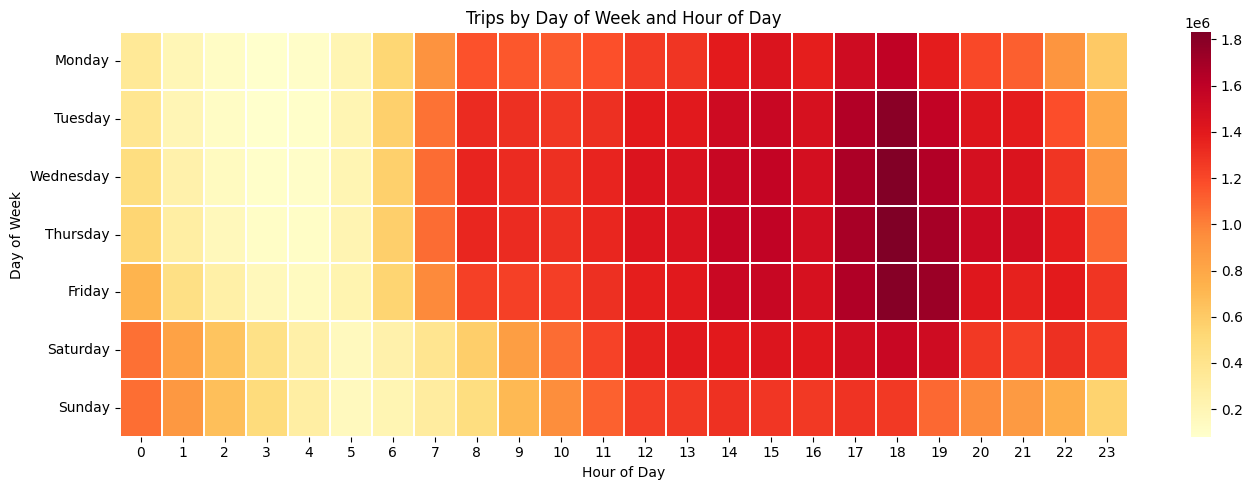

In [ ]:
plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white"
)

plt.title("Trips by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

**Taxi demand per month**

In [ ]:
ddf["pickup_month_num"] = ddf["tpep_pickup_datetime"].dt.month
ddf["pickup_month_name"] = ddf["tpep_pickup_datetime"].dt.month_name()

ddf["pickup_month"] = (
    ddf["tpep_pickup_datetime"]
       .dt.to_period("M")
       .dt.to_timestamp()
)

In [ ]:
trips_by_month = (
    ddf.groupby(["pickup_month_num", "pickup_month_name"])
       .size()
       .compute()
       .reset_index(name="trip_count")
       .sort_values("pickup_month_num")
)

trips_by_month

,pickup_month_num,pickup_month_name,trip_count
7,1,January,17879512
9,2,February,17639880
5,3,March,16366193
0,4,April,13437574
1,5,May,13990920
2,6,June,13857476
8,7,July,13051869
6,8,August,12962325
3,9,September,13994110
10,10,October,14503655


In [ ]:
trips_by_month_all_years = (
    ddf.groupby("pickup_month")
       .size()
       .compute()
       .reset_index(name="trip_count")
       .sort_values("pickup_month")
)

trips_by_month_all_years.head()

,pickup_month,trip_count
0,2019-01-01,7689223
19,2019-02-01,7039678
8,2019-03-01,7854548
36,2019-04-01,7463943
9,2019-05-01,7584782


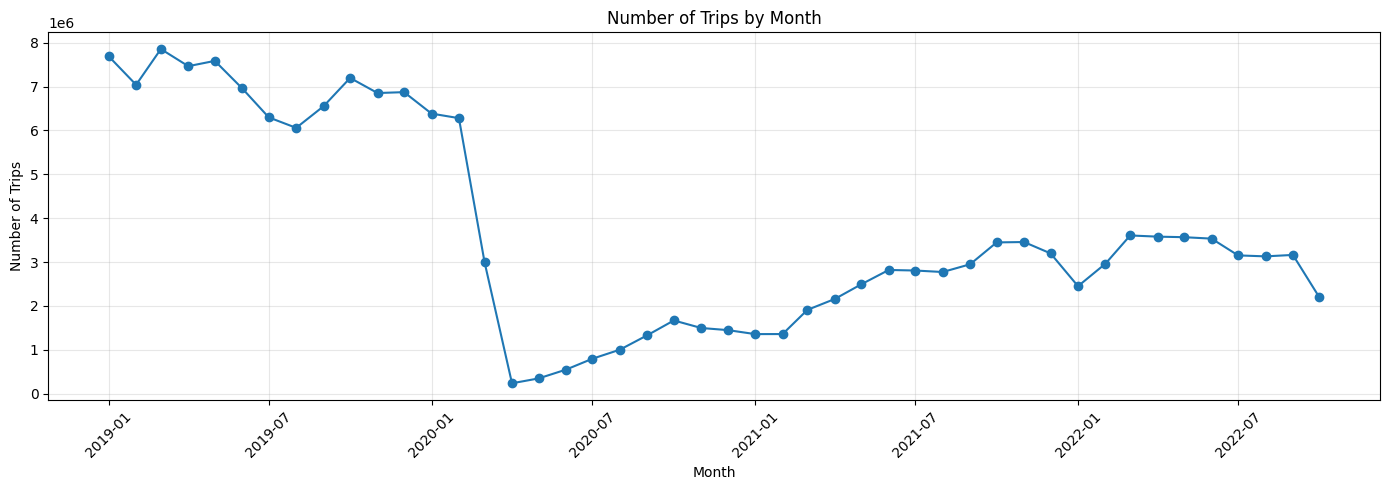

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    trips_by_month_all_years["pickup_month"],
    trips_by_month_all_years["trip_count"],
    marker="o"
)

plt.title("Number of Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plotting the number of taxi trips by month from **2019 to 2022** shows a clear drop in taxi trip frequency starting around **March 2020**, which is likely related to the COVID-19 pandemic. After this period, the number of trips slowly starts to increase again.

### 2.2 Fare and Trip Distance Analysis

**Average Fare per Mile by Pickup Hour**

Plotting the average fare per mile by pickup hour shows that taxi pricing is highest during the early morning and afternoon hours, with the peak occurring around **05:00** and **16:00**. Lower average fare per mile values are observed during late evening hours between **20:00 and 23:00**.

In [ ]:
fare_per_mile_df = ddf[
    ddf["trip_distance"].notnull()
    & (ddf["trip_distance"] > 0)
    & ddf["fare_amount"].notnull()
]

fare_per_mile_df = fare_per_mile_df.assign(
    fare_per_mile=(
        fare_per_mile_df["fare_amount"]
        / fare_per_mile_df["trip_distance"]
    )
)

In [ ]:
avg_fare_per_mile_by_hour = (
    fare_per_mile_df.groupby("pickup_hour_of_day")["fare_per_mile"]
        .mean()
        .compute()
        .reset_index(name="avg_fare_per_mile")
        .sort_values("pickup_hour_of_day")
)

avg_fare_per_mile_by_hour

,pickup_hour_of_day,avg_fare_per_mile
0,0,7.364847
16,1,7.470701
11,2,7.305208
1,3,7.749664
17,4,9.135671
2,5,9.611046
7,6,7.891427
22,7,7.437303
12,8,7.838352
13,9,8.177242


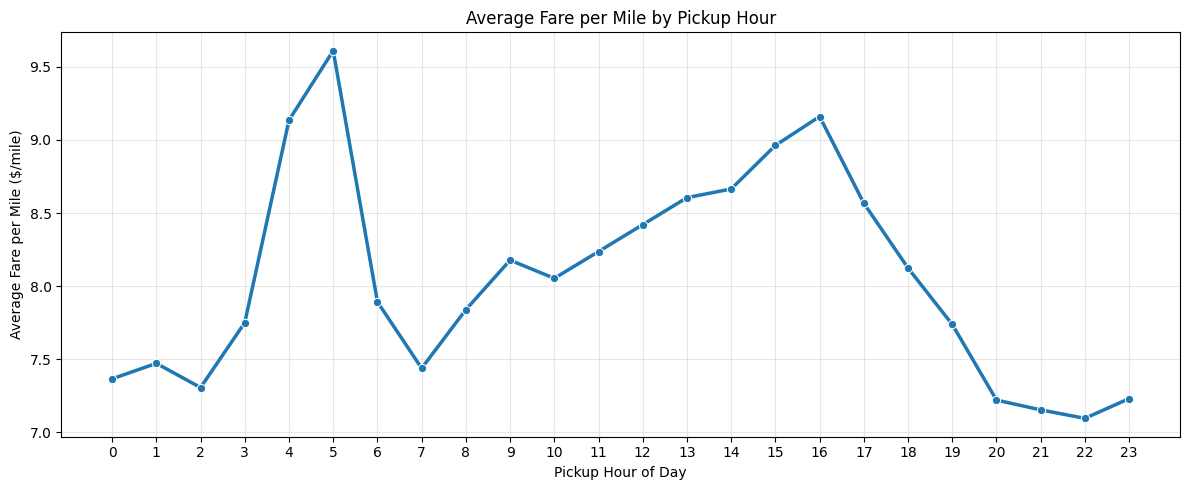

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=avg_fare_per_mile_by_hour,
    x="pickup_hour_of_day",
    y="avg_fare_per_mile",
    marker="o",
    linewidth=2.5
)

plt.title("Average Fare per Mile by Pickup Hour")
plt.xlabel("Pickup Hour of Day")
plt.ylabel("Average Fare per Mile ($/mile)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Average Fare per Mile by Vendor and Pickup Hour**


In [ ]:
vendor_counts = (ddf["VendorID"].value_counts().compute())

vendor_counts

VendorID
4.0       267080
6.0       152990
5.0          592
2.0    113710081
1.0     56874666
Name: count, dtype: int64

In [ ]:
vendor_fpm_df = ddf[
    ddf["pickup_hour_of_day"].notnull()
    & ddf["VendorID"].notnull()
    & ddf["fare_amount"].notnull()
    & ddf["trip_distance"].notnull()
    & (ddf["trip_distance"] > 0)
]

vendor_fpm_df = vendor_fpm_df.assign(
    fare_per_mile=(
        vendor_fpm_df["fare_amount"]
        / vendor_fpm_df["trip_distance"]
    )
)

In [ ]:
avg_fpm_by_vendor_hour = (
    vendor_fpm_df
    .groupby(["VendorID", "pickup_hour_of_day"])["fare_per_mile"]
    .mean()
    .compute()
    .reset_index(name="avg_fare_per_mile")
    .sort_values(["VendorID", "pickup_hour_of_day"])
)

avg_fpm_by_vendor_hour

,VendorID,pickup_hour_of_day,avg_fare_per_mile
49,1.0,0,5.237953
93,1.0,1,5.284306
35,1.0,2,5.239966
0,1.0,3,5.257285
50,1.0,4,5.248157
...,...,...,...
70,6.0,19,5.804333
88,6.0,20,5.019371
45,6.0,21,5.304416
15,6.0,22,5.405457


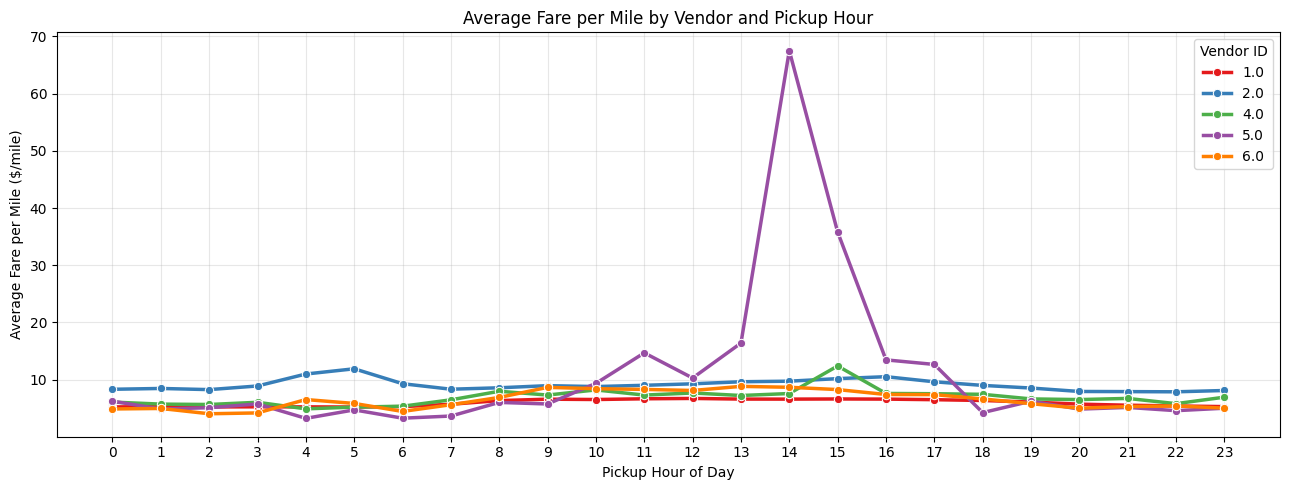

In [ ]:
plt.figure(figsize=(13, 5))

sns.lineplot(
    data=avg_fpm_by_vendor_hour,
    x="pickup_hour_of_day",
    y="avg_fare_per_mile",
    hue="VendorID",
    palette="Set1",   
    marker="o",
    linewidth=2.5
)

plt.title("Average Fare per Mile by Vendor and Pickup Hour")
plt.xlabel("Pickup Hour of Day")
plt.ylabel("Average Fare per Mile ($/mile)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title="Vendor ID")
plt.tight_layout()
plt.show()

Vendor IDs **1** and **2** are the two dominant vendors in the dataset, with Vendor **2** having the highest number of trips overall. Comparing the average fare per mile between the two vendors shows that Vendor **2** is generally more expensive than Vendor **1** across most hours of the day.

Vendor **5** shows a noticeable peak in average fare per mile around **14:00**, however, it appears very rarely in the dataset compared to the other vendors.

### 2.3 Spatial Analysis

In [ ]:
zones_lookup = zones[["LocationID", "borough", "zone", "geometry"]].copy()

pickup_zone_counts = (
    ddf.groupby("PULocationID")
       .size()
       .compute()
       .reset_index(name="pickup_count")
       .sort_values("pickup_count", ascending=False)
)

pickup_zone_counts.head(20)

,PULocationID,pickup_count
214,237,7781113
161,236,7092043
139,161,6720382
41,186,5928049
28,132,5850907
201,162,5841160
246,170,5292752
241,142,5269685
157,230,5265439
67,48,5245554


In [ ]:
pickup_zone_counts_named = pickup_zone_counts.merge(
    zones_lookup.drop(columns="geometry"),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

top_pickup_zones = pickup_zone_counts_named.head(20)

top_pickup_zones

,PULocationID,pickup_count,LocationID,borough,zone
0,237,7781113,237.0,Manhattan,Upper East Side South
1,236,7092043,236.0,Manhattan,Upper East Side North
2,161,6720382,161.0,Manhattan,Midtown Center
3,186,5928049,186.0,Manhattan,Penn Station/Madison Sq West
4,132,5850907,132.0,Queens,JFK Airport
5,162,5841160,162.0,Manhattan,Midtown East
6,170,5292752,170.0,Manhattan,Murray Hill
7,142,5269685,142.0,Manhattan,Lincoln Square East
8,230,5265439,230.0,Manhattan,Times Sq/Theatre District
9,48,5245554,48.0,Manhattan,Clinton East


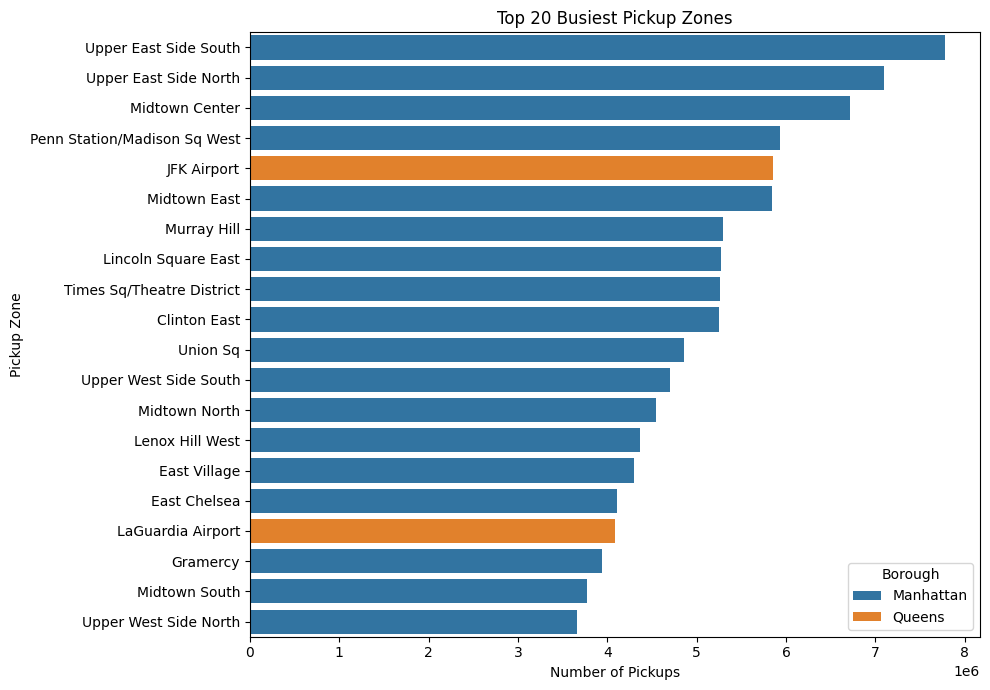

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_pickup_zones,
    y="zone",
    x="pickup_count",
    hue="borough",
    dodge=False
)

plt.title("Top 20 Busiest Pickup Zones")
plt.xlabel("Number of Pickups")
plt.ylabel("Pickup Zone")
plt.legend(title="Borough")
plt.tight_layout()
plt.show()

In [ ]:
pickup_map = zones.merge(
    pickup_zone_counts,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

pickup_map["pickup_count"] = (
    pickup_map["pickup_count"]
    .fillna(0)
)

In [ ]:
dropoff_zone_counts = (
    ddf.groupby("DOLocationID")
       .size()
       .compute()
       .reset_index(name="dropoff_count")
       .sort_values("dropoff_count", ascending=False)
)

dropoff_zone_counts_named = dropoff_zone_counts.merge(
    zones_lookup.drop(columns="geometry"),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

dropoff_zone_counts_named.head(20)

,DOLocationID,dropoff_count,LocationID,borough,zone
0,236,7307390,236.0,Manhattan,Upper East Side North
1,237,6877604,237.0,Manhattan,Upper East Side South
2,161,6227417,161.0,Manhattan,Midtown Center
3,170,5226007,170.0,Manhattan,Murray Hill
4,162,4808406,162.0,Manhattan,Midtown East
5,230,4724288,230.0,Manhattan,Times Sq/Theatre District
6,142,4645582,142.0,Manhattan,Lincoln Square East
7,48,4603141,48.0,Manhattan,Clinton East
8,239,4537188,239.0,Manhattan,Upper West Side South
9,141,4483928,141.0,Manhattan,Lenox Hill West


In [ ]:
dropoff_map = zones.merge(
    dropoff_zone_counts,
    left_on="LocationID",
    right_on="DOLocationID",
    how="left"
)

dropoff_map["dropoff_count"] = (
    dropoff_map["dropoff_count"]
    .fillna(0)
)

pickup_map["log_pickup_count"] = np.log1p(
    pickup_map["pickup_count"]
)

dropoff_map["log_dropoff_count"] = np.log1p(
    dropoff_map["dropoff_count"]
)

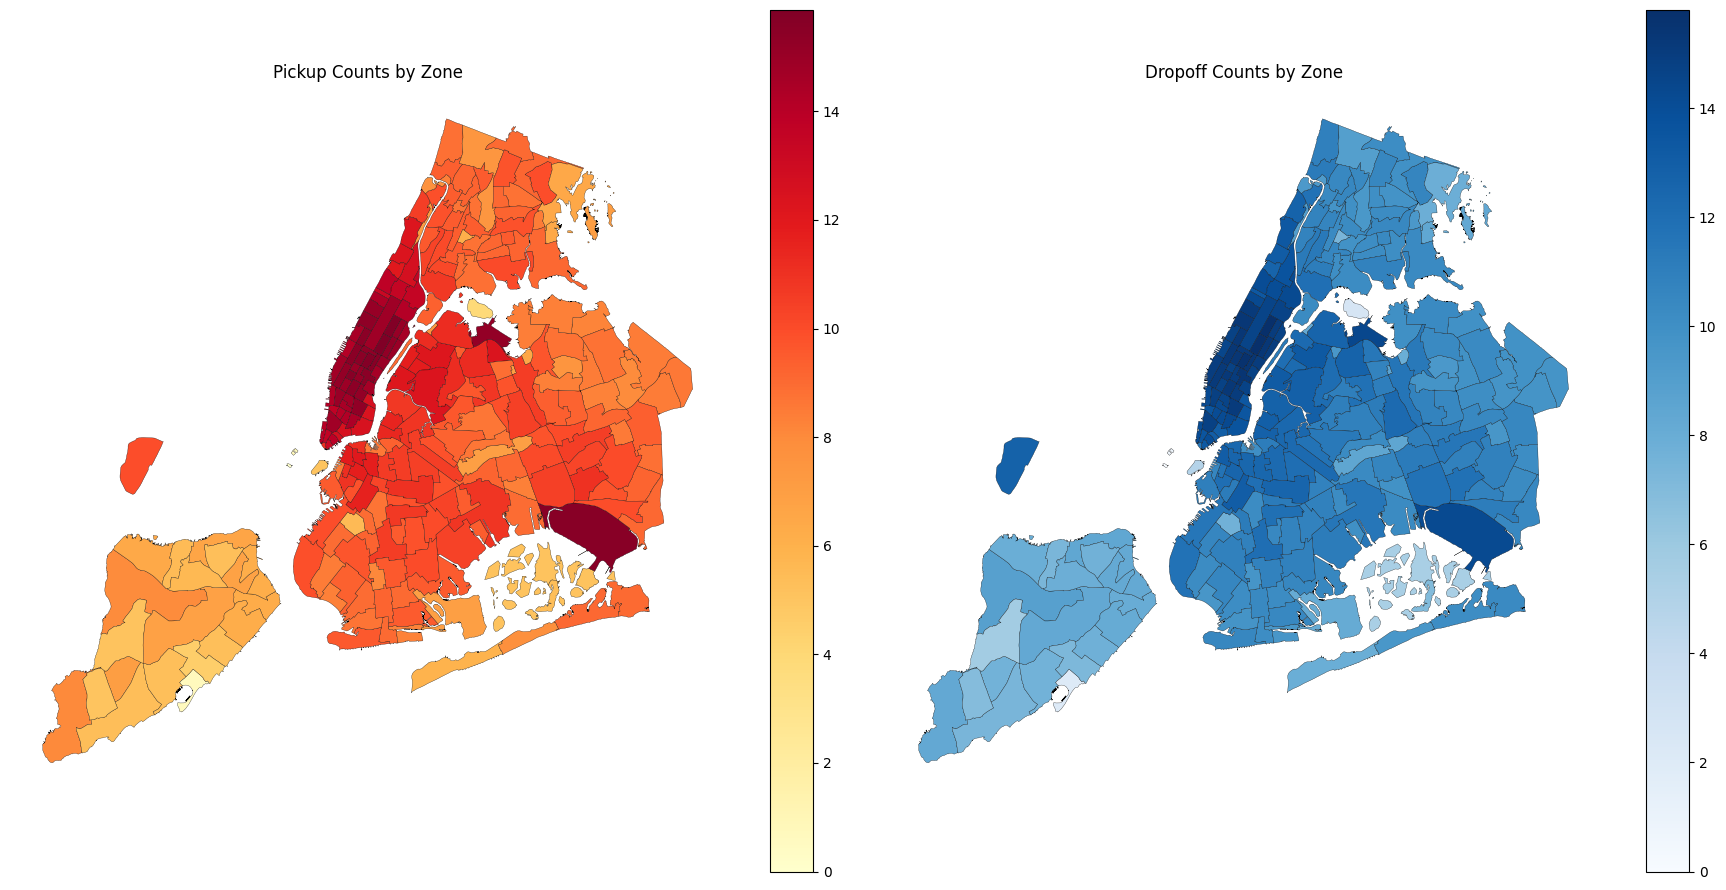

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

pickup_map.plot(
    column="log_pickup_count",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)

axes[0].set_title("Pickup Counts by Zone")
axes[0].axis("off")

dropoff_map.plot(
    column="log_dropoff_count",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=axes[1]
)

axes[1].set_title("Dropoff Counts by Zone")
axes[1].axis("off")

plt.tight_layout()
plt.show()

The spatial analysis shows that taxi pickups and dropoffs are most concentrated around **Manhattan**, as well as around the major airport zones including **JFK Airport** and **LaGuardia Airport**. This is expected, since the Yellow Taxi dataset mainly contains trips from Manhattan and airport-related areas.

Following Manhattan, the highest taxi activity is in **Brooklyn** and **Queens**, while the lowest activity is visible in **Staten Island** and the **Bronx**.

### 2.4 Enriched Data Analysis

#### 2.4.1 Weather Data

**Average Precipitation vs Taxi Demand**

We compare the average daily precipitation with the total number of taxi trips per day to check possible correlation between weather conditions and taxi demand, where rainy or snowy days are expected to result in higher trip counts.

In [ ]:
year = 2019

df_year = ddf[ddf["tpep_pickup_datetime"].dt.year == year]

df_year = df_year.assign(pickup_date=df_year["tpep_pickup_datetime"].dt.date)

daily_weather_trips = (
    df_year.groupby("pickup_date")
    .agg({
        "tpep_pickup_datetime": "size",
        "precipitation_mm": "mean"
    })
    .compute()
    .reset_index()
)


In [ ]:
daily_weather_trips = daily_weather_trips.rename(columns={
    "tpep_pickup_datetime": "trip_count",
    "precipitation_mm": "avg_precipitation_mm"
})

daily_weather_trips["pickup_date"] = pd.to_datetime(
    daily_weather_trips["pickup_date"]
)

daily_weather_trips = daily_weather_trips.sort_values("pickup_date")
daily_weather_trips.head()

,pickup_date,trip_count,avg_precipitation_mm
250,2019-01-01,189195,1.009348
278,2019-01-02,198521,0.000000
299,2019-01-03,223733,0.000000
173,2019-01-04,235860,0.000000
42,2019-01-05,236286,0.549721


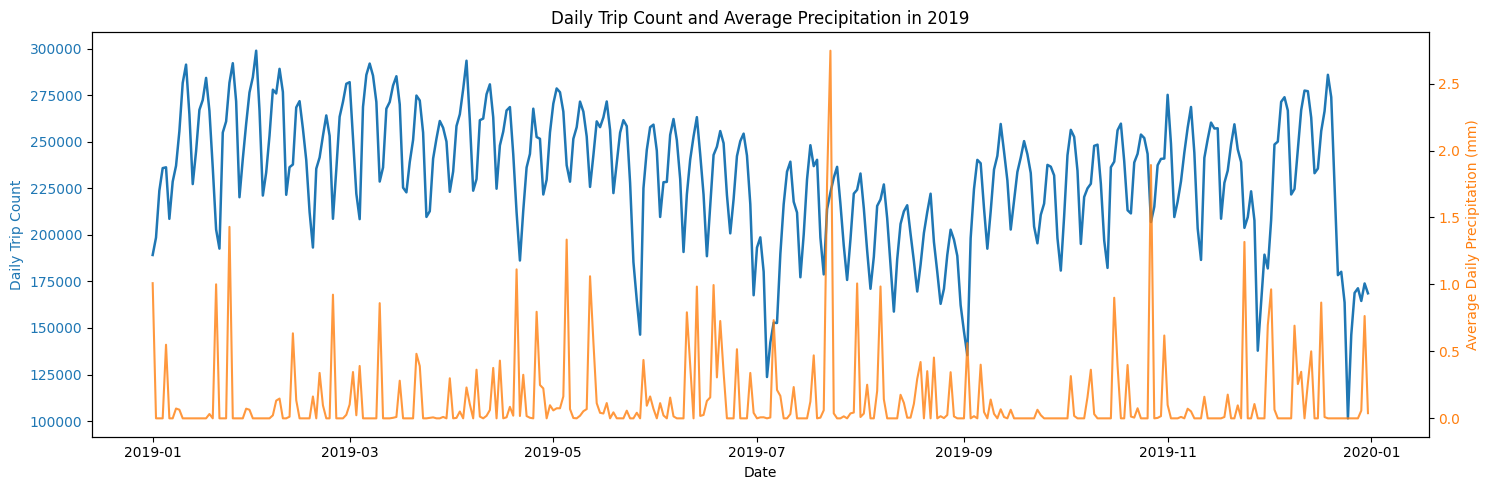

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(
    daily_weather_trips["pickup_date"],
    daily_weather_trips["trip_count"],
    linewidth=1.8,
    color="tab:blue",
    label="Daily Trip Count"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Daily Trip Count", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    daily_weather_trips["pickup_date"],
    daily_weather_trips["avg_precipitation_mm"],
    linewidth=1.5,
    color="tab:orange",
    alpha=0.8,
    label="Avg Daily Precipitation"
)

ax2.set_ylabel(
    "Average Daily Precipitation (mm)",
    color="tab:orange"
)

ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title(
    f"Daily Trip Count and Average Precipitation in {year}"
)

fig.tight_layout()
plt.show()

From the plot, we can see a relationship between average precipitation and taxi demand. Peaks in precipitation often occur around similar periods as changes in daily trip counts, showing that weather conditions can affect taxi usage.

**Average Temperature vs Taxi Demand**

Next, we compare how different temperature ranges affect the average hourly number of taxi trips. We expect extremely low and extremely high temperatures to result in higher taxi demand.

In [ ]:
df_temp = ddf.assign(
    pickup_date=ddf["tpep_pickup_datetime"].dt.date
)

# group by pickup date and calculate daily trip counts and average temperature
daily_temp_trips = (
    df_temp.groupby("pickup_date")
    .agg({
        "tpep_pickup_datetime": "size",
        "temperature_c": "mean"
    })
    .compute()
    .reset_index()
)

daily_temp_trips = daily_temp_trips.rename(columns={
    "tpep_pickup_datetime": "trip_count",
    "temperature_c": "avg_temperature_c"
})

daily_temp_trips["pickup_date"] = pd.to_datetime(
    daily_temp_trips["pickup_date"]
)

daily_temp_trips = daily_temp_trips.sort_values("pickup_date")
daily_temp_trips.head()

,pickup_date,trip_count,avg_temperature_c
1101,2019-01-01,189195,10.014934
1066,2019-01-02,198521,2.735113
994,2019-01-03,223733,5.024880
638,2019-01-04,235860,3.447027
211,2019-01-05,236286,6.422875


In [ ]:
# group temperature into ranges 
ddf = ddf.assign(
    temp_bin=ddf["temperature_c"].map_partitions(
        pd.cut,
        bins=list(range(-20, 45, 3))
    )
)

In [ ]:
# trips by temperature ranges 
temp_period_counts = (
    ddf.groupby(
        ["temp_bin", "pickup_time_hour"],
        observed=True
    )
    .size()
    .compute()
    .reset_index(name="trip_count")
)

avg_trips_by_temp = (
    temp_period_counts
    .groupby("temp_bin", observed=True)["trip_count"]
    .mean()
    .reset_index(name="avg_trip_count")
)

avg_trips_by_temp

,temp_bin,avg_trip_count
0,"(-17, -14]",10415.687500
1,"(-14, -11]",6346.437500
2,"(-11, -8]",5574.556818
3,"(-8, -5]",5753.365729
4,"(-5, -2]",5928.927993
5,"(-2, 1]",5711.619390
6,"(1, 4]",5767.462728
7,"(4, 7]",5575.723155
8,"(7, 10]",5063.254876
9,"(10, 13]",4893.224092


From the results, we can observe that taxi demand is generally higher during extremely low and extremely high temperature ranges. The highest average trip counts occur at temperatures below **-14°C** and above **34°C**, while moderate temperature ranges show lower average taxi demand.

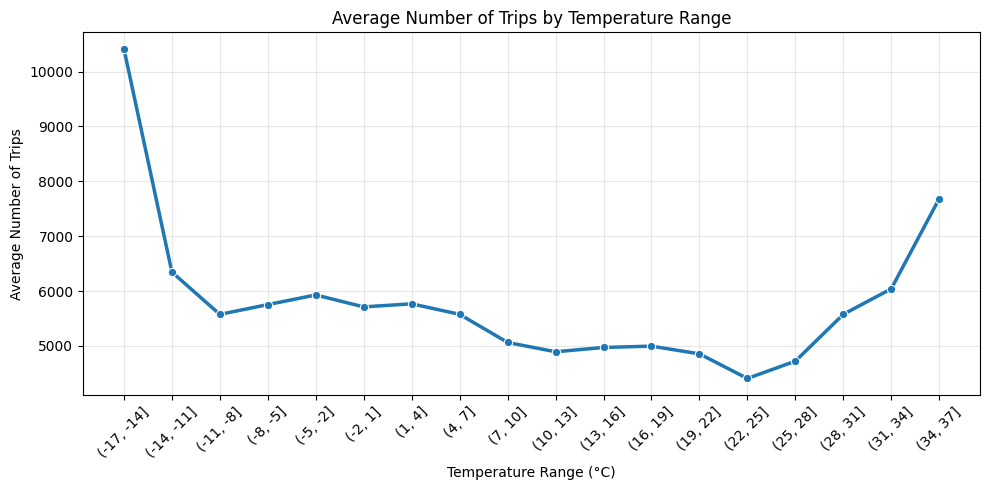

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=avg_trips_by_temp,
    x=avg_trips_by_temp["temp_bin"].astype(str),
    y="avg_trip_count",
    marker="o",
    linewidth=2.5
)

plt.title("Average Number of Trips by Temperature Range")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Number of Trips")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.4.2 School Data

**School Density vs Taxi Demand**

We compare the number of schools in each taxi zone with total taxi activity in the same zone. The goal is to check whether zones with more schools also have higher taxi demand.

In [ ]:
school_path = Path(
    "data/schools_and_events/SchoolPoints_APS_2024_08_28/"
    "SchoolPoints_APS_2024_08_28.shp"
)

schools = gpd.read_file(school_path)

In [ ]:
# assign schools to taxi zones
zones_proj = zones.to_crs(epsg=2263)
schools_proj = schools.to_crs(zones_proj.crs)

schools_with_zone = gpd.sjoin(
    schools_proj,
    zones_proj[["LocationID", "borough", "zone", "geometry"]],
    how="left",
    predicate="within"
)

school_counts = (
    schools_with_zone
    .groupby("LocationID")
    .size()
    .reset_index(name="school_count")
)

In [ ]:
# taxi activity by zone (pick up + drop off)
pickup_counts = (
    ddf.groupby("PULocationID")
       .size()
       .compute()
       .reset_index(name="pickup_count")
       .rename(columns={"PULocationID": "LocationID"})
)

dropoff_counts = (
    ddf.groupby("DOLocationID")
       .size()
       .compute()
       .reset_index(name="dropoff_count")
       .rename(columns={"DOLocationID": "LocationID"})
)

In [ ]:
school_taxi_zone = zones_proj[
    ["LocationID", "borough", "zone", "geometry"]
].copy()

school_taxi_zone = school_taxi_zone.merge(
    school_counts,
    on="LocationID",
    how="left"
)

school_taxi_zone = school_taxi_zone.merge(
    pickup_counts,
    on="LocationID",
    how="left"
)

school_taxi_zone = school_taxi_zone.merge(
    dropoff_counts,
    on="LocationID",
    how="left"
)

school_taxi_zone[
    ["school_count", "pickup_count", "dropoff_count"]
] = school_taxi_zone[
    ["school_count", "pickup_count", "dropoff_count"]
].fillna(0)

school_taxi_zone["total_taxi_activity"] = (
    school_taxi_zone["pickup_count"]
    + school_taxi_zone["dropoff_count"]
)

school_taxi_zone["log_total_taxi_activity"] = np.log1p(
    school_taxi_zone["total_taxi_activity"]
)

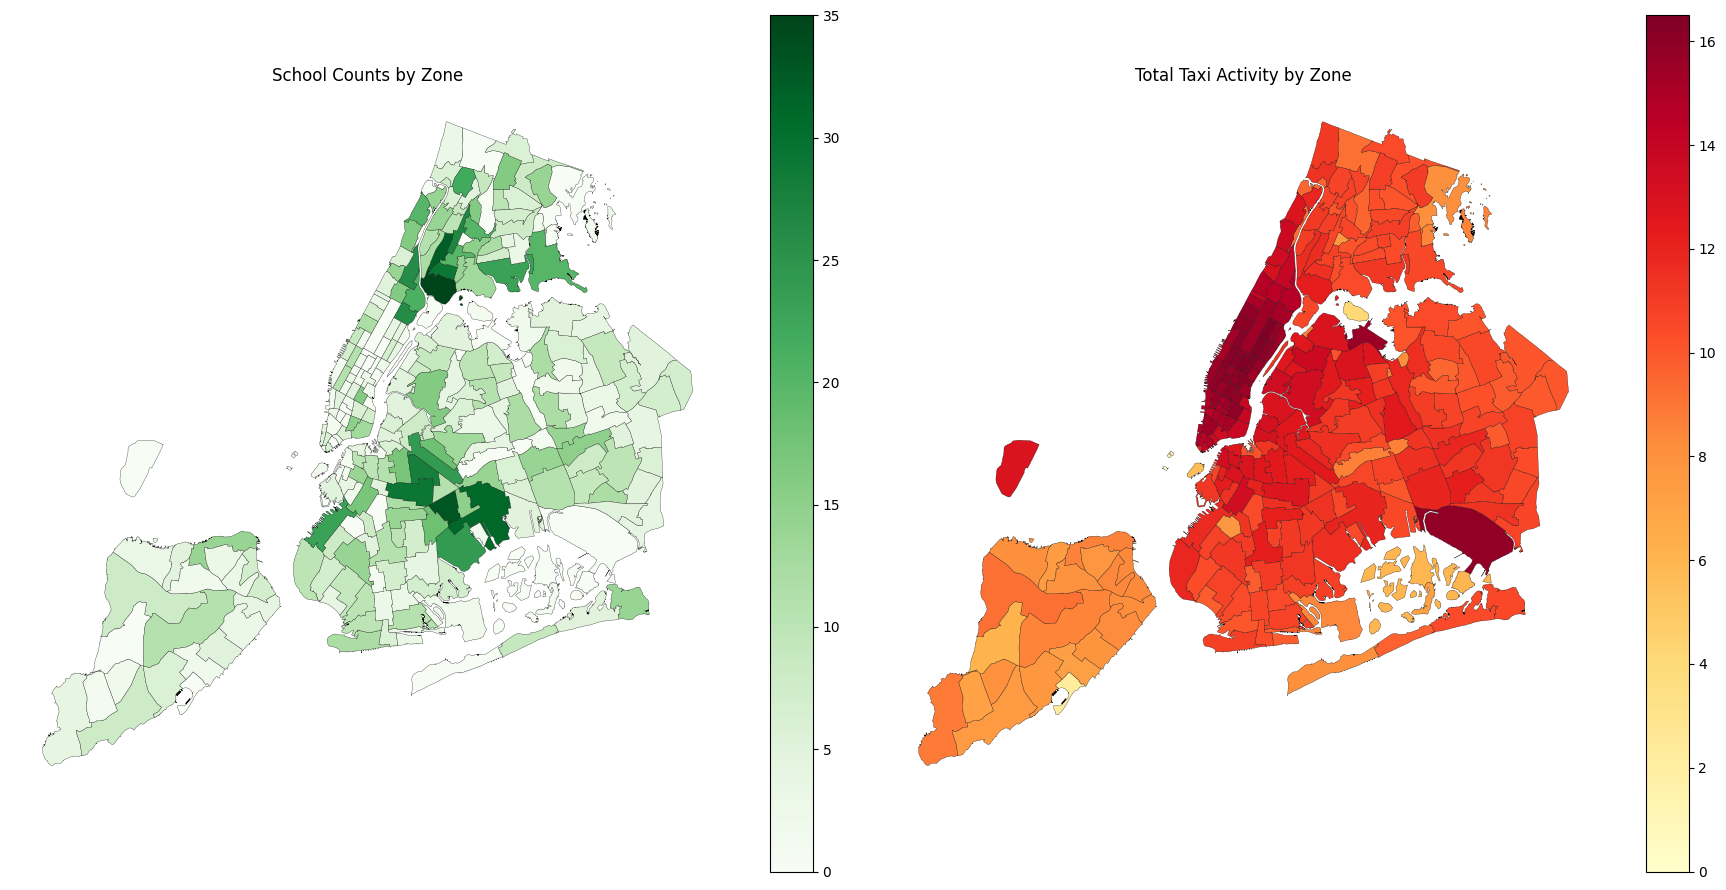

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

school_taxi_zone.plot(
    column="school_count",
    cmap="Greens",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)

axes[0].set_title("School Counts by Zone")
axes[0].axis("off")

school_taxi_zone.plot(
    column="log_total_taxi_activity",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=axes[1]
)

axes[1].set_title("Total Taxi Activity by Zone")
axes[1].axis("off")

plt.tight_layout()
plt.show()

From the spatial comparison, we can observe that zones with high taxi activity do not necessarily correspond to zones with high school density. The highest taxi activity is concentrated mainly in Manhattan, while the highest school density zones in the available data appear mostly in Brooklyn and in areas between Manhattan and the Bronx.

#### 2.4.3 Business and Attractions Data

**Business Density vs Fare Amount**

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

businesses = pd.read_csv("data/business_and_attractions/businesses_20260406.csv")

print("shape:", businesses.shape)
print("missing coords:", businesses[["Latitude", "Longitude"]].isna().sum().to_dict())
print(businesses.columns.tolist())

businesses = businesses.dropna(subset=["Latitude", "Longitude"]).copy()
businesses["Community Board"] = businesses["Community Board"].astype("Int64", errors="ignore")
businesses["Council District"] = businesses["Council District"].astype("Int64", errors="ignore")

businesses.head()

shape: (69231, 8)
missing coords: {'Latitude': 23624, 'Longitude': 23624}
['Business Name', 'Community Board', 'Council District', 'BIN', 'BBL', 'Census Tract (2010)', 'Latitude', 'Longitude']


,Business Name,Community Board,Council District,BIN,BBL,Census Tract (2010),Latitude,Longitude
0,"GREGORY ULTO, INC.",318,45,3217486.0,3.078250e+09,730.0,40.62446,-73.932304
1,YA.K.K INC,103,1,1001812.0,1.001640e+09,29.0,40.71573,-73.998788
2,"PROCESS SERVER PLUS, INC.",409,32,4188647.0,4.090710e+09,38.0,40.68463,-73.844767
3,BROADWAY BEER AND SMOKE INC.,401,22,4008258.0,4.006110e+09,59.0,40.76188,-73.925212
4,NEW YORK GINSENG CITY INC,407,20,4112315.0,4.049760e+09,871.0,40.75913,-73.831422


In [ ]:
businesses["geometry"] = businesses.apply(
    lambda row: Point(row["Longitude"], row["Latitude"]),
    axis=1
)

gdf_businesses = gpd.GeoDataFrame(businesses, geometry="geometry", crs="EPSG:4326")

zones_wgs84 = zones.to_crs("EPSG:4326")

businesses_zones = gpd.sjoin(
    gdf_businesses,
    zones_wgs84[["LocationID", "borough", "zone", "geometry"]],
    how="left",
    predicate="intersects"
)

business_zone_counts = (
    businesses_zones.groupby(["LocationID", "borough", "zone"])
    .size()
    .reset_index(name="business_count")
    .sort_values("business_count", ascending=False)
)

business_zone_counts.head(15)

,LocationID,borough,zone,business_count
204,216.0,Queens,South Ozone Park,693
121,130.0,Queens,Jamaica,644
18,22.0,Brooklyn,Bensonhurst West,614
120,129.0,Queens,Jackson Heights,594
187,197.0,Queens,Richmond Hill,580
88,92.0,Queens,Flushing,569
152,161.0,Manhattan,Midtown Center,562
85,89.0,Brooklyn,Flatbush/Ditmas Park,518
4,7.0,Queens,Astoria,506
188,198.0,Queens,Ridgewood,488


In [ ]:
pickup_counts = (
    ddf.groupby("PULocationID")
    .size()
    .compute()
    .reset_index(name="pickup_count")
    .rename(columns={"PULocationID": "LocationID"})
)

business_taxi_compare = business_zone_counts.merge(
    pickup_counts,
    on="LocationID",
    how="left"
).fillna({"pickup_count": 0})

business_taxi_compare = business_taxi_compare.sort_values(
    ["business_count", "pickup_count"],
    ascending=[False, False]
)

business_taxi_compare.head(20)

,LocationID,borough,zone,business_count,pickup_count
0,216.0,Queens,South Ozone Park,693,34107
1,130.0,Queens,Jamaica,644,35595
2,22.0,Brooklyn,Bensonhurst West,614,10952
3,129.0,Queens,Jackson Heights,594,74518
4,197.0,Queens,Richmond Hill,580,23593
5,92.0,Queens,Flushing,569,16495
6,161.0,Manhattan,Midtown Center,562,6720382
7,89.0,Brooklyn,Flatbush/Ditmas Park,518,38493
8,7.0,Queens,Astoria,506,200165
9,198.0,Queens,Ridgewood,488,10304


In [ ]:
# Calculate average taxi pickups per business
business_taxi_compare["pickup_per_business"] = (
    business_taxi_compare["pickup_count"]
    / (business_taxi_compare["business_count"] + 1)
)

# Top 15 highest
top_pickup_per_business = (
    business_taxi_compare
    .nlargest(15, "pickup_per_business")
)

# Top 15 lowest
low_pickup_per_business = (
    business_taxi_compare
    .nsmallest(15, "pickup_per_business")
)

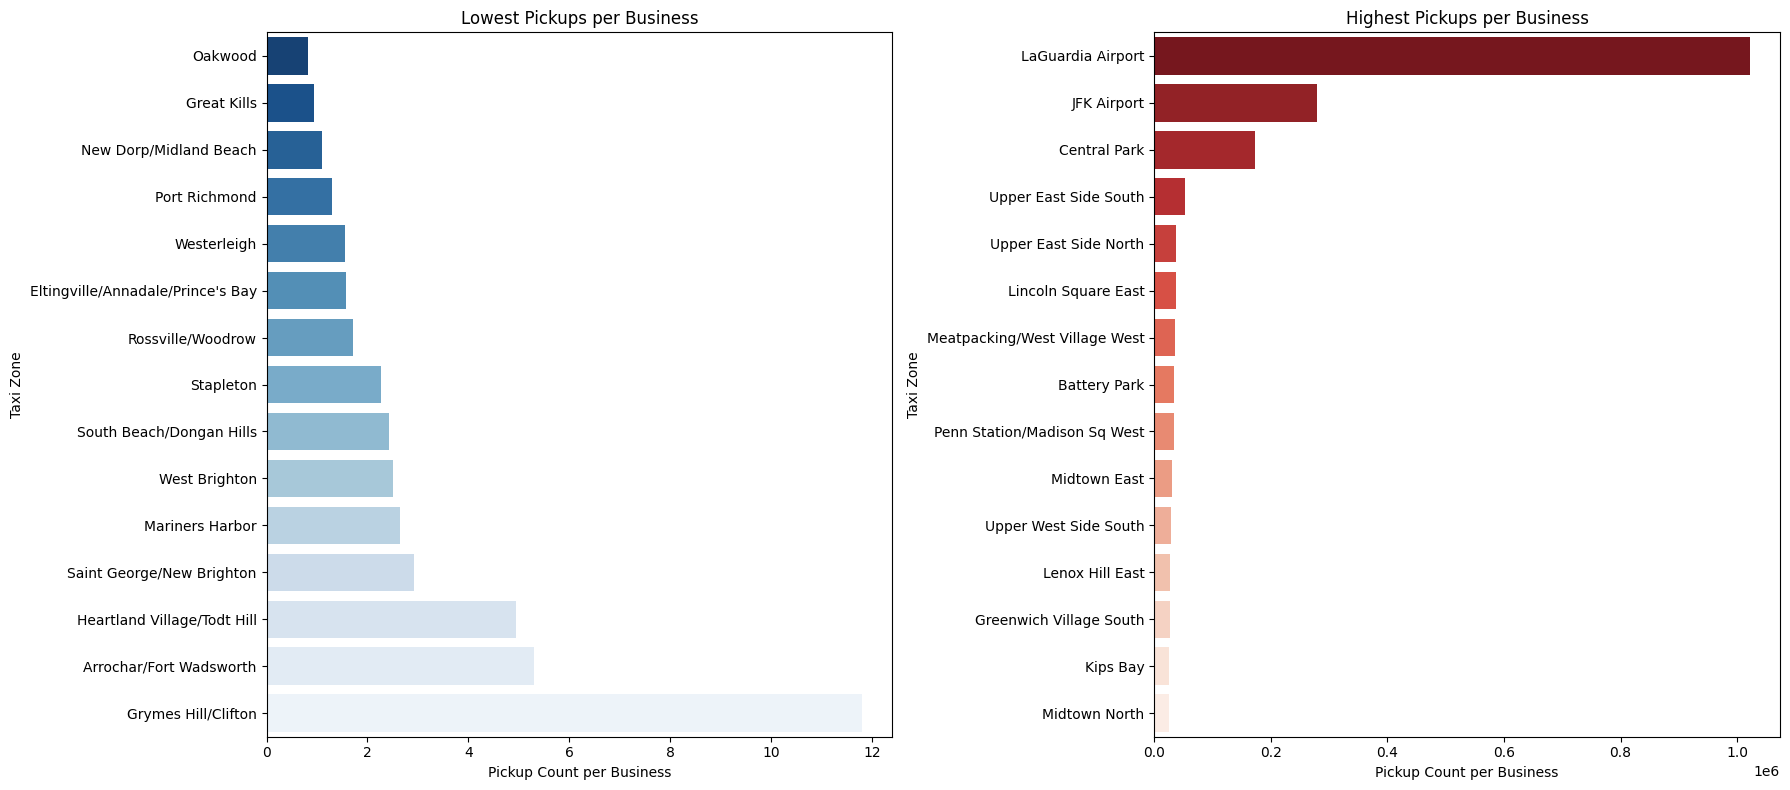

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Lowest pickups per business
sns.barplot(
    data=low_pickup_per_business,
    x="pickup_per_business",
    y="zone",
    palette="Blues_r",
    ax=axes[0]
)

axes[0].set_title("Lowest Pickups per Business")
axes[0].set_xlabel("Pickup Count per Business")
axes[0].set_ylabel("Taxi Zone")

# Highest pickups per business
sns.barplot(
    data=top_pickup_per_business,
    x="pickup_per_business",
    y="zone",
    palette="Reds_r",
    ax=axes[1]
)

axes[1].set_title("Highest Pickups per Business")
axes[1].set_xlabel("Pickup Count per Business")
axes[1].set_ylabel("Taxi Zone")

plt.tight_layout()
plt.show()

The results show that businesses in airports and central Manhattan areas are related to much higher taxi activity, while mostly residential Staten Island zones generate fewer taxi pickups per business.

## 3. DuckDB and Dask SQL Comparison

In this section, we repeat several  tasks using DuckDB and Dask SQL and compare execution times.


In [18]:
performance_results = []

def timed_query(task, engine, query_fn):
    start = time.perf_counter()
    result = query_fn()
    seconds = time.perf_counter() - start

    performance_results.append({
        "task": task,
        "engine": engine,
        "seconds": seconds
    })

    return result

In [19]:
comparison_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "total_amount",
]

ddf_sql = dd.read_parquet(
    "data/*.parquet",
    engine="pyarrow",
    columns=comparison_columns
)

ddf_sql = ddf_sql[
    ddf_sql["tpep_pickup_datetime"].notnull()
    & ddf_sql["tpep_dropoff_datetime"].notnull()
    & (ddf_sql["tpep_dropoff_datetime"] >= ddf_sql["tpep_pickup_datetime"])
    & (ddf_sql["tpep_pickup_datetime"] >= "2019-01-01")
    & (ddf_sql["tpep_pickup_datetime"] < "2023-01-01")
    & (ddf_sql["trip_distance"] >= 0)
    & (ddf_sql["trip_distance"] <= 300)
    & (ddf_sql["passenger_count"] >= 0)
    & (ddf_sql["passenger_count"] <= 8)
    & (ddf_sql["fare_amount"] >= 0)
    & (ddf_sql["total_amount"] >= 0)
    & (ddf_sql["total_amount"] <= 1000)
]

ddf_sql = ddf_sql.assign(
    pickup_hour_of_day=ddf_sql["tpep_pickup_datetime"].dt.hour,
    fare_per_mile=ddf_sql["fare_amount"] / ddf_sql["trip_distance"]
)

c = Context()
c.create_table("trips", ddf_sql)


In [20]:
# Create a cleaned DuckDB view using the same filtering logic

duckdb.sql("""
CREATE OR REPLACE VIEW clean_trips AS
SELECT
    *,
    EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour_of_day,
    fare_amount / NULLIF(trip_distance, 0) AS fare_per_mile
FROM read_parquet('data/*.parquet')
WHERE
    tpep_pickup_datetime IS NOT NULL
    AND tpep_dropoff_datetime IS NOT NULL
    AND tpep_dropoff_datetime >= tpep_pickup_datetime
    AND tpep_pickup_datetime >= TIMESTAMP '2019-01-01'
    AND tpep_pickup_datetime < TIMESTAMP '2023-01-01'
    AND trip_distance >= 0
    AND trip_distance <= 300
    AND passenger_count >= 0
    AND passenger_count <= 8
    AND fare_amount >= 0
    AND total_amount >= 0
    AND total_amount <= 1000
""")


**Row count**

We count the total number of rows in the cleaned dataset to confirm that both DuckDB and Dask SQL are working with the same number of trips.

In [22]:
# row count
duckdb_row_count = timed_query(
    "Row count",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT COUNT(*) AS row_count
        FROM clean_trips
    """).df()
)


dasksql_row_count = timed_query(
    "Row count",
    "Dask SQL",
    lambda: c.sql("""
        SELECT COUNT(*) AS row_count
        FROM trips
    """).compute()
)

duckdb_row_count, dasksql_row_count


(   row_count
 0  167293862,
    row_count
 0  167293862)

**Trips by hour**

We group all trips by `pickup_hour_of_day`, count the total number of trips for each hour, and order the results by hour of the day.

In [23]:
duckdb_trips_by_hour = timed_query(
    "Trips by hour",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            pickup_hour_of_day,
            COUNT(*) AS trip_count
        FROM clean_trips
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).df()
)

dasksql_trips_by_hour = timed_query(
    "Trips by hour",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            pickup_hour_of_day,
            COUNT(*) AS trip_count
        FROM trips
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).compute()
)

duckdb_trips_by_hour.head(), dasksql_trips_by_hour.head()


(   pickup_hour_of_day  trip_count
 0                   0     4484406
 1                   1     3040192
 2                   2     2065567
 3                   3     1409549
 4                   4     1045226,
     pickup_hour_of_day  trip_count
 16                   0     4484406
 22                   1     3040192
 23                   2     2065567
 19                   3     1409549
 7                    4     1045226)

**Average fare per mile by hour**

We filter the trips to include only trips where `trip_distance` is greater than 0, group them by `pickup_hour_of_day`, calculate the average `fare_per_mile` for each hour, and order the results by hour of the day.

In [24]:
# average fare per mile by hour

duckdb_fare_per_mile = timed_query(
    "Average fare per mile by hour",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            pickup_hour_of_day,
            AVG(fare_per_mile) AS avg_fare_per_mile
        FROM clean_trips
        WHERE trip_distance > 0
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).df()
)

dasksql_fare_per_mile = timed_query(
    "Average fare per mile by hour",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            pickup_hour_of_day,
            AVG(fare_per_mile) AS avg_fare_per_mile
        FROM trips
        WHERE trip_distance > 0
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).compute()
)

duckdb_fare_per_mile.head(), dasksql_fare_per_mile.head()


(   pickup_hour_of_day  avg_fare_per_mile
 0                   0           7.342122
 1                   1           7.431050
 2                   2           7.262836
 3                   3           7.679053
 4                   4           9.082778,
     pickup_hour_of_day  avg_fare_per_mile
 16                   0           7.342122
 22                   1           7.431050
 23                   2           7.262836
 19                   3           7.679053
 7                    4           9.082778)

**Top pickup locations**

We group all trips by `PULocationID`, count the total number of pickups for each location, sort the results from highest to lowest pickup count, and return the top 20 pickup locations.

In [25]:
duckdb_top_pickups = timed_query(
    "Top pickup locations",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            PULocationID,
            COUNT(*) AS pickup_count
        FROM clean_trips
        GROUP BY PULocationID
        ORDER BY pickup_count DESC
        LIMIT 20
    """).df()
)

dasksql_top_pickups = timed_query(
    "Top pickup locations",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            "PULocationID",
            COUNT(*) AS pickup_count
        FROM trips
        GROUP BY "PULocationID"
        ORDER BY pickup_count DESC
        LIMIT 20
    """).compute()
)


duckdb_top_pickups.head(), dasksql_top_pickups.head()


(   PULocationID  pickup_count
 0           237       7712494
 1           236       7009347
 2           161       6667264
 3           186       5893357
 4           132       5842977,
     PULocationID  pickup_count
 9            237       7712494
 14           236       7009347
 4            161       6667264
 16           186       5893357
 7            132       5842977)

**Average trip distance by passenger count**

We group all trips by `passenger_count`, calculate the average `trip_distance`, count the total number of trips for each passenger count, and order the results by `passenger_count`.

In [26]:

duckdb_distance_by_passengers = timed_query(
    "Average distance by passengers",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            passenger_count,
            AVG(trip_distance) AS avg_trip_distance,
            COUNT(*) AS trip_count
        FROM clean_trips
        GROUP BY passenger_count
        ORDER BY passenger_count
    """).df()
)

dasksql_distance_by_passengers = timed_query(
    "Average distance by passengers",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            passenger_count,
            AVG(trip_distance) AS avg_trip_distance,
            COUNT(*) AS trip_count
        FROM trips
        GROUP BY passenger_count
        ORDER BY passenger_count
    """).compute()
)

duckdb_distance_by_passengers.head(), dasksql_distance_by_passengers.head()


(   passenger_count  avg_trip_distance  trip_count
 0              0.0           2.793192     3346529
 1              1.0           2.989220   120181514
 2              2.0           3.299745    25093539
 3              3.0           3.205077     6817801
 4              4.0           3.323791     3097593,
    passenger_count  avg_trip_distance  trip_count
 6              0.0           2.793192     3346529
 1              1.0           2.989220   120181514
 0              2.0           3.299745    25093539
 2              3.0           3.205077     6817801
 4              4.0           3.323791     3097593)

**Average total amount by hour**

We group all trips by `pickup_hour_of_day`, calculate the average `total_amount` for each hour, and order the results by hour of the day.

In [27]:
duckdb_total_by_hour = timed_query(
    "Average total amount by hour",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            pickup_hour_of_day,
            AVG(total_amount) AS avg_total_amount
        FROM clean_trips
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).df()
)

dasksql_total_by_hour = timed_query(
    "Average total amount by hour",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            pickup_hour_of_day,
            AVG(total_amount) AS avg_total_amount
        FROM trips
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).compute()
)

duckdb_total_by_hour.head(), dasksql_total_by_hour.head()


(   pickup_hour_of_day  avg_total_amount
 0                   0         20.460961
 1                   1         19.303418
 2                   2         18.496049
 3                   3         19.109206
 4                   4         22.461107,
     pickup_hour_of_day  avg_total_amount
 16                   0         20.460961
 22                   1         19.303418
 23                   2         18.496049
 19                   3         19.109206
 7                    4         22.461107)

**Top dropoff locations**

We group all trips by `DOLocationID`, count the total number of dropoffs for each location, sort the results from highest to lowest dropoff count, and return the top 20 dropoff locations.

In [28]:

duckdb_top_dropoffs = timed_query(
    "Top dropoff locations",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            DOLocationID,
            COUNT(*) AS dropoff_count
        FROM clean_trips
        GROUP BY DOLocationID
        ORDER BY dropoff_count DESC
        LIMIT 20
    """).df()
)

dasksql_top_dropoffs = timed_query(
    "Top dropoff locations",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            "DOLocationID",
            COUNT(*) AS dropoff_count
        FROM trips
        GROUP BY "DOLocationID"
        ORDER BY dropoff_count DESC
        LIMIT 20
    """).compute()
)

duckdb_top_dropoffs.head(), dasksql_top_dropoffs.head()


(   DOLocationID  dropoff_count
 0           236        7225039
 1           237        6810863
 2           161        6163209
 3           170        5159264
 4           162        4760839,
     DOLocationID  dropoff_count
 15           236        7225039
 11           237        6810863
 1            161        6163209
 25           170        5159264
 12           162        4760839)

**Fare and distance by passengers**

We group all trips by `passenger_count`, calculate the average `fare_amount`, calculate the average `trip_distance`, count the total number of trips for each passenger count, and order the results by `passenger_count`.

In [29]:
duckdb_fare_distance_by_passengers = timed_query(
    "Fare and distance by passengers",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            passenger_count,
            AVG(fare_amount) AS avg_fare_amount,
            AVG(trip_distance) AS avg_trip_distance,
            COUNT(*) AS trip_count
        FROM clean_trips
        GROUP BY passenger_count
        ORDER BY passenger_count
    """).df()
)

dasksql_fare_distance_by_passengers = timed_query(
    "Fare and distance by passengers",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            passenger_count,
            AVG(fare_amount) AS avg_fare_amount,
            AVG(trip_distance) AS avg_trip_distance,
            COUNT(*) AS trip_count
        FROM trips
        GROUP BY passenger_count
        ORDER BY passenger_count
    """).compute()
)

duckdb_fare_distance_by_passengers.head(), dasksql_fare_distance_by_passengers.head()


(   passenger_count  avg_fare_amount  avg_trip_distance  trip_count
 0              0.0        12.719633           2.793192     3346529
 1              1.0        13.081417           2.989220   120181514
 2              2.0        14.055163           3.299745    25093539
 3              3.0        13.868407           3.205077     6817801
 4              4.0        14.548924           3.323791     3097593,
    passenger_count  avg_fare_amount  avg_trip_distance  trip_count
 6              0.0        12.719633           2.793192     3346529
 1              1.0        13.081417           2.989220   120181514
 0              2.0        14.055163           3.299745    25093539
 2              3.0        13.868407           3.205077     6817801
 4              4.0        14.548924           3.323791     3097593)

**Long trips by hour**

We filter the trips to include only long trips where `trip_distance` is at least 10 miles, group them by `pickup_hour_of_day`, count the number of long trips for each hour, and order the results by hour of the day.

In [30]:
duckdb_long_trips_by_hour = timed_query(
    "Long trips by hour",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            pickup_hour_of_day,
            COUNT(*) AS long_trip_count
        FROM clean_trips
        WHERE trip_distance >= 10
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).df()
)

dasksql_long_trips_by_hour = timed_query(
    "Long trips by hour",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            pickup_hour_of_day,
            COUNT(*) AS long_trip_count
        FROM trips
        WHERE trip_distance >= 10
        GROUP BY pickup_hour_of_day
        ORDER BY pickup_hour_of_day
    """).compute()
)

duckdb_long_trips_by_hour.head(), dasksql_long_trips_by_hour.head()


(   pickup_hour_of_day  long_trip_count
 0                   0           338695
 1                   1           177168
 2                   2            92494
 3                   3            79396
 4                   4           121140,
     pickup_hour_of_day  long_trip_count
 15                   0           338695
 22                   1           177168
 23                   2            92494
 19                   3            79396
 7                    4           121140)

**Most expensive pickup hours**

We group all trips by `pickup_hour_of_day`, calculate the average `total_amount`, count the total number of trips, and return the 10 most expensive hours of the day.

In [31]:
# most expensive pickup hours

duckdb_expensive_hours = timed_query(
    "Most expensive pickup hours",
    "DuckDB",
    lambda: duckdb.sql("""
        SELECT
            pickup_hour_of_day,
            AVG(total_amount) AS avg_total_amount,
            COUNT(*) AS trip_count
        FROM clean_trips
        GROUP BY pickup_hour_of_day
        ORDER BY avg_total_amount DESC
        LIMIT 10
    """).df()
)

dasksql_expensive_hours = timed_query(
    "Most expensive pickup hours",
    "Dask SQL",
    lambda: c.sql("""
        SELECT
            pickup_hour_of_day,
            AVG(total_amount) AS avg_total_amount,
            COUNT(*) AS trip_count
        FROM trips
        GROUP BY pickup_hour_of_day
        ORDER BY avg_total_amount DESC
        LIMIT 10
    """).compute()
)

duckdb_expensive_hours.head(), dasksql_expensive_hours.head()


(   pickup_hour_of_day  avg_total_amount  trip_count
 0                   5         24.322543     1278766
 1                   4         22.461107     1045226
 2                  16         20.797395     9758490
 3                   0         20.460961     4484406
 4                  23         20.372297     6340396,
     pickup_hour_of_day  avg_total_amount  trip_count
 14                   5         24.322543     1278766
 7                    4         22.461107     1045226
 21                  16         20.797395     9758490
 16                   0         20.460961     4484406
 2                   23         20.372297     6340396)

In [32]:
# Final comparison table

performance_df = pd.DataFrame(performance_results)

performance_table = (
    performance_df
    .pivot(index="task", columns="engine", values="seconds")
    .reset_index()
)

performance_table["faster_engine"] = performance_table.apply(
    lambda row: "DuckDB" if row["DuckDB"] < row["Dask SQL"] else "Dask SQL",
    axis=1
)

performance_table["speedup"] = (
    performance_table[["DuckDB", "Dask SQL"]].max(axis=1)
    / performance_table[["DuckDB", "Dask SQL"]].min(axis=1)
)

performance_table


engine,task,Dask SQL,DuckDB,faster_engine,speedup
0,Average distance by passengers,2.775267,0.392367,DuckDB,7.073147
1,Average fare per mile by hour,3.118461,0.480910,DuckDB,6.484495
2,Average total amount by hour,2.788520,0.441907,DuckDB,6.310196
3,Fare and distance by passengers,2.955429,0.395162,DuckDB,7.479042
4,Long trips by hour,2.677446,0.206439,DuckDB,12.969673
5,Most expensive pickup hours,2.919620,0.441102,DuckDB,6.618924
6,Row count,2.553885,0.385654,DuckDB,6.622213
7,Top dropoff locations,2.990884,0.392060,DuckDB,7.628635
8,Top pickup locations,3.058579,0.395884,DuckDB,7.725957
9,Trips by hour,2.632665,0.422301,DuckDB,6.234101


From the results, we can see that Dask SQL was slower because the queries were executed locally on a single machine and were not distributed across multiple workers. DuckDB was faster for all tested queries, with a speedup between around 6.4x and 9.0x.

## 4. Performance Comparison Across Data Formats and Libraries

### 4.1 Preparing Benchmark Datasets

For benchmarking purposes, we use a reduced subset of columns that are shared across all implementations.

We create:
- a benchmark parquet dataset,
- a benchmark CSV dataset.

In [ ]:
# benchmark columns = comparison columns + any additional columns needed for the queries
benchmark_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "total_amount",
]

# Load enriched parquet dataset
ddf = dd.read_parquet(
    "data/*.parquet",
    engine="pyarrow",
    columns=benchmark_columns
)

# Apply preprocessing / cleaning
ddf = ddf[
    ddf["tpep_pickup_datetime"].notnull()
    & ddf["tpep_dropoff_datetime"].notnull()
    & (
        ddf["tpep_dropoff_datetime"]
        >= ddf["tpep_pickup_datetime"]
    )
    & (ddf["trip_distance"] >= 0)
    & (ddf["trip_distance"] <= 300)
    & (ddf["passenger_count"] >= 0)
    & (ddf["passenger_count"] <= 8)
    & (ddf["fare_amount"] >= 0)
    & (ddf["total_amount"] >= 0)
    & (ddf["total_amount"] <= 1000)
]

ddf_2019 = ddf[
    (ddf["tpep_pickup_datetime"] >= "2019-01-01")
    & (ddf["tpep_pickup_datetime"] < "2020-01-01")
]

In [21]:
benchmark_dir = Path("benchmark_data")
parquet_dir = benchmark_dir / "parquet"
csv_dir = benchmark_dir / "csv"

benchmark_dir.mkdir(exist_ok=True)

if parquet_dir.exists():
    shutil.rmtree(parquet_dir)

if csv_dir.exists():
    shutil.rmtree(csv_dir)

parquet_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

ddf_2019.to_parquet(
    str(parquet_dir),
    write_index=False,
    overwrite=True,
)

ddf_2019.to_csv(
    str(csv_dir / "data-*.csv"),
    index=False,
)

['/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-00.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-01.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-02.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-03.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-04.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-05.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-06.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-07.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-08.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-09.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-10.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/data-11.csv',
 '/d/hpc/projects/FRI/bigdata/students/sm_bv/benchmark_data/csv/

### 4.2 Benchmark Methodology

Each library is tested on **five representative tasks** that cover the most common analytical operations on this dataset:

1. **Row count** = Full-scan I/O with minimal computation
2. **Average trip distance** = Single-column aggregation
3. **Top 10 pickup locations** = GROUP BY + ORDER BY + LIMIT
4. **Trips by pickup hour** = GROUP BY on a derived (datetime) column
5. **Average fare by passenger count** = GROUP BY on a low-cardinality categorical column.

Each task is timed *individually* for every library–format pair. This allows us to identify the most appropriate tool per task, rather than only comparing total runtimes. The measured time includes data loading, query execution, and result materialisation.

In [7]:
benchmark_results = []   # {"Library", "Format", "Task", "Time (s)"}

csv_files = glob("benchmark_data/csv/*.csv")

def run_benchmark(task, library, fmt, func):
    start = time.perf_counter()
    result = func()
    elapsed = time.perf_counter() - start

    benchmark_results.append({
        "Library": library,
        "Format": fmt,
        "Task": task,
        "Time (s)": elapsed,
    })

    print(f"[{library} + {fmt}] {task}: {elapsed:.4f} s")
    return result

### 4.3 Pandas

Pandas performs eager, in-memory computation. It is the simplest tool to use and integrates naturally with the rest of the Python data science stack, but it requires the entire dataset to fit in RAM.

In [8]:
#  CSV
pdf_csv = run_benchmark(
    "Row count", "Pandas", "CSV",
    lambda: pd.concat(
        [pd.read_csv(f, parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"])
         for f in csv_files],
        ignore_index=True
    )
)
print(f"  → {len(pdf_csv):,} rows loaded")

run_benchmark("Avg trip distance",  "Pandas", "CSV",
    lambda: pdf_csv["trip_distance"].mean())

run_benchmark("Top pickup locations", "Pandas", "CSV",
    lambda: pdf_csv.groupby("PULocationID").size().sort_values(ascending=False).head(10))

run_benchmark("Trips by pickup hour", "Pandas", "CSV",
    lambda: pdf_csv.groupby(pdf_csv["tpep_pickup_datetime"].dt.hour).size())

run_benchmark("Avg fare by passenger count", "Pandas", "CSV",
    lambda: pdf_csv.groupby("passenger_count")["total_amount"].mean())

[Pandas + CSV] Row count: 118.6345 s
  → 83,981,888 rows loaded
[Pandas + CSV] Avg trip distance: 0.1150 s
[Pandas + CSV] Top pickup locations: 0.7238 s
[Pandas + CSV] Trips by pickup hour: 2.2027 s
[Pandas + CSV] Avg fare by passenger count: 1.3753 s


passenger_count
0.0    18.706662
1.0    18.915536
2.0    19.669074
3.0    19.419971
4.0    19.835884
5.0    18.957490
6.0    18.882159
7.0    66.252524
8.0    72.543248
Name: total_amount, dtype: float64

In [9]:
#  Parquet
pdf_pq = run_benchmark(
    "Row count", "Pandas", "Parquet",
    lambda: pd.read_parquet("benchmark_data/parquet")
)
print(f"  → {len(pdf_pq):,} rows loaded")

run_benchmark("Avg trip distance",  "Pandas", "Parquet",
    lambda: pdf_pq["trip_distance"].mean())

run_benchmark("Top pickup locations", "Pandas", "Parquet",
    lambda: pdf_pq.groupby("PULocationID").size().sort_values(ascending=False).head(10))

run_benchmark("Trips by pickup hour", "Pandas", "Parquet",
    lambda: pdf_pq.groupby(pdf_pq["tpep_pickup_datetime"].dt.hour).size())

run_benchmark("Avg fare by passenger count", "Pandas", "Parquet",
    lambda: pdf_pq.groupby("passenger_count")["total_amount"].mean())

[Pandas + Parquet] Row count: 2.9472 s
  → 83,981,888 rows loaded
[Pandas + Parquet] Avg trip distance: 0.1693 s
[Pandas + Parquet] Top pickup locations: 1.3147 s
[Pandas + Parquet] Trips by pickup hour: 2.5181 s
[Pandas + Parquet] Avg fare by passenger count: 1.5065 s


passenger_count
0.0    18.706662
1.0    18.915536
2.0    19.669074
3.0    19.419971
4.0    19.835884
5.0    18.957490
6.0    18.882159
7.0    66.252524
8.0    72.543248
Name: total_amount, dtype: float64

### 4.4 Dask

Dask enables lazy, parallel, out-of-core computation by partitioning data across cores. Unlike Pandas, it does not require the full dataset to be in memory at once. Computation is deferred until `.compute()` is called.

In [10]:
# CSV
# Dask reads lazily, so datetime parsing is done explicitly after read.
ddf_csv = dd.read_csv("benchmark_data/csv/*.csv", assume_missing=True)
ddf_csv["tpep_pickup_datetime"] = dd.to_datetime(ddf_csv["tpep_pickup_datetime"])

run_benchmark("Row count", "Dask", "CSV",
    lambda: ddf_csv.shape[0].compute())

run_benchmark("Avg trip distance", "Dask", "CSV",
    lambda: ddf_csv["trip_distance"].mean().compute())

run_benchmark("Top pickup locations", "Dask", "CSV",
    lambda: ddf_csv.groupby("PULocationID").size().nlargest(10).compute())

run_benchmark("Trips by pickup hour", "Dask", "CSV",
    lambda: ddf_csv.groupby(ddf_csv["tpep_pickup_datetime"].dt.hour).size().compute())

run_benchmark("Avg fare by passenger count", "Dask", "CSV",
    lambda: ddf_csv.groupby("passenger_count")["total_amount"].mean().compute())

[Dask + CSV] Row count: 89.6562 s
[Dask + CSV] Avg trip distance: 5.5117 s
[Dask + CSV] Top pickup locations: 6.2338 s
[Dask + CSV] Trips by pickup hour: 85.1021 s
[Dask + CSV] Avg fare by passenger count: 6.8842 s


passenger_count
6.0    18.882159
2.0    19.669074
3.0    19.419971
0.0    18.706662
5.0    18.957490
1.0    18.915536
8.0    72.543248
7.0    66.252524
4.0    19.835884
Name: total_amount, dtype: float64

In [11]:
# Parquet 
ddf_pq = dd.read_parquet("benchmark_data/parquet")

run_benchmark("Row count", "Dask", "Parquet",
    lambda: ddf_pq.shape[0].compute())

run_benchmark("Avg trip distance", "Dask", "Parquet",
    lambda: ddf_pq["trip_distance"].mean().compute())

run_benchmark("Top pickup locations", "Dask", "Parquet",
    lambda: ddf_pq.groupby("PULocationID").size().nlargest(10).compute())

run_benchmark("Trips by pickup hour", "Dask", "Parquet",
    lambda: ddf_pq.groupby(ddf_pq["tpep_pickup_datetime"].dt.hour).size().compute())

run_benchmark("Avg fare by passenger count", "Dask", "Parquet",
    lambda: ddf_pq.groupby("passenger_count")["total_amount"].mean().compute())

[Dask + Parquet] Row count: 0.0234 s
[Dask + Parquet] Avg trip distance: 0.6026 s
[Dask + Parquet] Top pickup locations: 0.8340 s
[Dask + Parquet] Trips by pickup hour: 1.7202 s
[Dask + Parquet] Avg fare by passenger count: 1.1513 s


passenger_count
0.0    18.706662
1.0    18.915536
2.0    19.669074
3.0    19.419971
4.0    19.835884
5.0    18.957490
6.0    18.882159
7.0    66.252524
8.0    72.543248
Name: total_amount, dtype: float64

### 4.5 DuckDB

DuckDB is an in-process analytical database with a vectorised, columnar execution engine. It reads Parquet files natively and can directly scan CSV via `read_csv_auto`. A new connection is created per benchmark run to avoid any caching effects.

In [12]:
# CSV 
con_duck_csv = duckdb.connect()
con_duck_csv.execute("""
    CREATE OR REPLACE VIEW taxi AS
    SELECT * FROM read_csv_auto('benchmark_data/csv/*.csv', union_by_name=true)
""")

run_benchmark("Row count", "DuckDB", "CSV",
    lambda: con_duck_csv.execute("SELECT COUNT(*) FROM taxi").fetchone()[0])

run_benchmark("Avg trip distance", "DuckDB", "CSV",
    lambda: con_duck_csv.execute("SELECT AVG(trip_distance) FROM taxi").fetchone()[0])

run_benchmark("Top pickup locations", "DuckDB", "CSV",
    lambda: con_duck_csv.execute("""
        SELECT PULocationID, COUNT(*) AS trip_count
        FROM taxi GROUP BY PULocationID ORDER BY trip_count DESC LIMIT 10
    """).fetchdf())

run_benchmark("Trips by pickup hour", "DuckDB", "CSV",
    lambda: con_duck_csv.execute("""
        SELECT EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour, COUNT(*) AS trip_count
        FROM taxi GROUP BY pickup_hour ORDER BY pickup_hour
    """).fetchdf())

run_benchmark("Avg fare by passenger count", "DuckDB", "CSV",
    lambda: con_duck_csv.execute("""
        SELECT passenger_count, AVG(total_amount) AS avg_total
        FROM taxi GROUP BY passenger_count ORDER BY passenger_count
    """).fetchdf())

[DuckDB + CSV] Row count: 2.0318 s
[DuckDB + CSV] Avg trip distance: 1.7874 s
[DuckDB + CSV] Top pickup locations: 1.5608 s
[DuckDB + CSV] Trips by pickup hour: 1.5848 s
[DuckDB + CSV] Avg fare by passenger count: 1.5038 s


,passenger_count,avg_total
0,0.0,18.706662
1,1.0,18.915536
2,2.0,19.669074
3,3.0,19.419971
4,4.0,19.835884
5,5.0,18.957490
6,6.0,18.882159
7,7.0,66.252524
8,8.0,72.543248


In [13]:
# Parquet
con_duck_pq = duckdb.connect()
con_duck_pq.execute("""
    CREATE OR REPLACE VIEW taxi AS
    SELECT * FROM parquet_scan('benchmark_data/parquet/*.parquet')
""")

run_benchmark("Row count", "DuckDB", "Parquet",
    lambda: con_duck_pq.execute("SELECT COUNT(*) FROM taxi").fetchone()[0])

run_benchmark("Avg trip distance", "DuckDB", "Parquet",
    lambda: con_duck_pq.execute("SELECT AVG(trip_distance) FROM taxi").fetchone()[0])

run_benchmark("Top pickup locations", "DuckDB", "Parquet",
    lambda: con_duck_pq.execute("""
        SELECT PULocationID, COUNT(*) AS trip_count
        FROM taxi GROUP BY PULocationID ORDER BY trip_count DESC LIMIT 10
    """).fetchdf())

run_benchmark("Trips by pickup hour", "DuckDB", "Parquet",
    lambda: con_duck_pq.execute("""
        SELECT EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour, COUNT(*) AS trip_count
        FROM taxi GROUP BY pickup_hour ORDER BY pickup_hour
    """).fetchdf())

run_benchmark("Avg fare by passenger count", "DuckDB", "Parquet",
    lambda: con_duck_pq.execute("""
        SELECT passenger_count, AVG(total_amount) AS avg_total
        FROM taxi GROUP BY passenger_count ORDER BY passenger_count
    """).fetchdf())

[DuckDB + Parquet] Row count: 0.0344 s
[DuckDB + Parquet] Avg trip distance: 0.0581 s
[DuckDB + Parquet] Top pickup locations: 0.0769 s
[DuckDB + Parquet] Trips by pickup hour: 0.1590 s
[DuckDB + Parquet] Avg fare by passenger count: 0.0865 s


,passenger_count,avg_total
0,0.0,18.706662
1,1.0,18.915536
2,2.0,19.669074
3,3.0,19.419971
4,4.0,19.835884
5,5.0,18.957490
6,6.0,18.882159
7,7.0,66.252524
8,8.0,72.543248


### 4.6 Dask-SQL

Dask-SQL layers a SQL interface on top of a Dask DataFrame. It translates SQL into a Dask task graph, which is then executed in parallel. It is useful when a pipeline already produces a Dask DataFrame and SQL expressiveness is preferred over the Dask API.

In [ ]:
# CSV
ddf_sql_csv = dd.read_csv("benchmark_data/csv/*.csv", assume_missing=True)
ddf_sql_csv["tpep_pickup_datetime"] = dd.to_datetime(ddf_sql_csv["tpep_pickup_datetime"])
ddf_sql_csv["tpep_dropoff_datetime"] = dd.to_datetime(ddf_sql_csv["tpep_dropoff_datetime"])  # added
ddf_sql_csv["pickup_hour_of_day"] = ddf_sql_csv["tpep_pickup_datetime"].dt.hour              # renamed

ctx_csv = Context()
ctx_csv.create_table("taxi", ddf_sql_csv)

run_benchmark("Row count", "Dask-SQL", "CSV",
    lambda: ctx_csv.sql("SELECT COUNT(*) AS n FROM taxi").compute())

run_benchmark("Avg trip distance", "Dask-SQL", "CSV",
    lambda: ctx_csv.sql("SELECT AVG(trip_distance) AS avg_dist FROM taxi").compute())

run_benchmark("Top pickup locations", "Dask-SQL", "CSV",
    lambda: ctx_csv.sql("""
        SELECT "PULocationID", COUNT(*) AS trip_count
        FROM taxi GROUP BY "PULocationID" ORDER BY trip_count DESC LIMIT 10
    """).compute())

run_benchmark("Trips by pickup hour", "Dask-SQL", "CSV",
    lambda: ctx_csv.sql("""
        SELECT pickup_hour_of_day, COUNT(*) AS trip_count
        FROM taxi GROUP BY pickup_hour_of_day ORDER BY pickup_hour_of_day
    """).compute())

run_benchmark("Avg fare by passenger count", "Dask-SQL", "CSV",
    lambda: ctx_csv.sql("""
        SELECT passenger_count, AVG(total_amount) AS avg_total
        FROM taxi GROUP BY passenger_count ORDER BY passenger_count
    """).compute())

[Dask-SQL + CSV] Row count: 92.2879 s
[Dask-SQL + CSV] Avg trip distance: 5.9887 s
[Dask-SQL + CSV] Top pickup locations: 6.1940 s
[Dask-SQL + CSV] Trips by pickup hour: 84.7747 s
[Dask-SQL + CSV] Avg fare by passenger count: 6.2207 s


,passenger_count,avg_total
6,0.0,18.706662
1,1.0,18.915536
0,2.0,19.669074
2,3.0,19.419971
4,4.0,19.835884
3,5.0,18.957490
5,6.0,18.882159
7,7.0,66.252524
8,8.0,72.543248


In [ ]:
# Parquet
ddf_sql_pq = dd.read_parquet("benchmark_data/parquet")
ddf_sql_pq["tpep_pickup_datetime"] = dd.to_datetime(ddf_sql_pq["tpep_pickup_datetime"])
ddf_sql_pq["tpep_dropoff_datetime"] = dd.to_datetime(ddf_sql_pq["tpep_dropoff_datetime"])
ddf_sql_pq["pickup_hour_of_day"] = ddf_sql_pq["tpep_pickup_datetime"].dt.hour

ctx_pq = Context()
ctx_pq.create_table("taxi", ddf_sql_pq)

run_benchmark("Row count", "Dask-SQL", "Parquet",
    lambda: ctx_pq.sql("SELECT COUNT(*) AS n FROM taxi").compute())

run_benchmark("Avg trip distance", "Dask-SQL", "Parquet",
    lambda: ctx_pq.sql("SELECT AVG(trip_distance) AS avg_dist FROM taxi").compute())

run_benchmark("Top pickup locations", "Dask-SQL", "Parquet",
    lambda: ctx_pq.sql("""
        SELECT "PULocationID", COUNT(*) AS trip_count
        FROM taxi GROUP BY "PULocationID" ORDER BY trip_count DESC LIMIT 10
    """).compute())

run_benchmark("Trips by pickup hour", "Dask-SQL", "Parquet",
    lambda: ctx_pq.sql("""
        SELECT pickup_hour_of_day, COUNT(*) AS trip_count
        FROM taxi GROUP BY pickup_hour_of_day ORDER BY pickup_hour_of_day
    """).compute())

run_benchmark("Avg fare by passenger count", "Dask-SQL", "Parquet",
    lambda: ctx_pq.sql("""
        SELECT passenger_count, AVG(total_amount) AS avg_total
        FROM taxi GROUP BY passenger_count ORDER BY passenger_count
    """).compute())

[Dask-SQL + Parquet] Row count: 1.2907 s
[Dask-SQL + Parquet] Avg trip distance: 1.1737 s
[Dask-SQL + Parquet] Top pickup locations: 0.9347 s
[Dask-SQL + Parquet] Trips by pickup hour: 1.7054 s
[Dask-SQL + Parquet] Avg fare by passenger count: 1.1840 s


,passenger_count,avg_total
6,0.0,18.706662
1,1.0,18.915536
0,2.0,19.669074
2,3.0,19.419971
4,4.0,19.835884
3,5.0,18.957490
5,6.0,18.882159
7,7.0,66.252524
8,8.0,72.543248


### 4.7 Results

In [16]:
results_df = pd.DataFrame(benchmark_results)
results_df["Library + Format"] = results_df["Library"] + " + " + results_df["Format"]

# Pivot: rows = tasks, columns = library+format combinations
pivot = (
    results_df
    .pivot(index="Task", columns="Library + Format", values="Time (s)")
    .round(3)
)

pivot

Library + Format,Dask + CSV,Dask + Parquet,Dask-SQL + CSV,Dask-SQL + Parquet,DuckDB + CSV,DuckDB + Parquet,Pandas + CSV,Pandas + Parquet
Task,,,,,,,,
Avg fare by passenger count,6.884,1.151,6.221,1.184,1.504,0.086,1.375,1.507
Avg trip distance,5.512,0.603,5.989,1.174,1.787,0.058,0.115,0.169
Row count,89.656,0.023,92.288,1.291,2.032,0.034,118.635,2.947
Top pickup locations,6.234,0.834,6.194,0.935,1.561,0.077,0.724,1.315
Trips by pickup hour,85.102,1.720,84.775,1.705,1.585,0.159,2.203,2.518


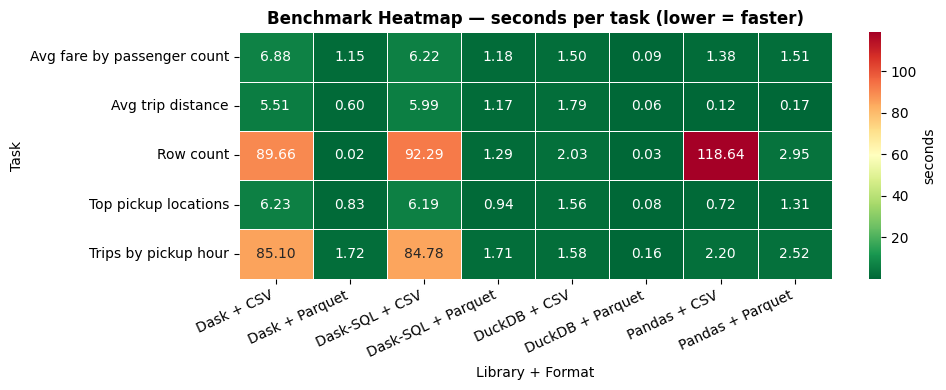

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "seconds"},
)
plt.title("Heatmap - seconds per task", fontweight="bold")
plt.xlabel("Library + Format")
plt.ylabel("Task")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 4.8 Conclusions

#### Parquet vs CSV

Parquet is faster across every library–task combination. The difference is largest for I/O-heavy tasks (row count, column aggregations) because Parquet is columnar and binary-encoded, the library reads only the bytes it needs and skips type parsing entirely. CSV is a text format with no schema: every field must be parsed on every read, and datetime columns require an additional conversion step. **CSV should only be preferred when human readability or compatibility with tools that do not support Parquet is required.**

#### Library choice: per task summary

Across all five tasks, **DuckDB + Parquet** was the fastest combination, with **Dask + Parquet** performing comparably on the row count task. Since no single task favoured a different library, recommendations are organised by use-case scenario rather than by task.

For analytical workloads on large tabular datasets:
- **DuckDB + Parquet** is the fastest combination for ad-hoc analytical queries. Its vectorised engine and native Parquet support make it the default choice for most tasks.
- **Dask + Parquet** is the right tool when the dataset exceeds available RAM, or when scalable distributed processing is needed.
- **Pandas + Parquet** is preferable for small-to-medium datasets that fit in memory and rapid exploratory analysis.
- **Dask-SQL + Parquet** is best when SQL syntax is preferred over the Dask API and the data is already in a Dask DataFrame.

The benchmark demonstrates the importance of selecting both *an appropriate storage format*, and *an appropriate execution engine* for large-scale data analytics.